In [10]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [26]:
#define state
class BMI(TypedDict):

    wt_kg: float
    height_m: float
    bmi:float
    category:str


In [27]:
def calculate_bmi(state: BMI) -> BMI:# input and output botj will  be state objects for a node (fucntion of node)
    wt=state['wt_kg']
    ht=state['height_m']
    bmi= wt/ht**2
    state['bmi']=round(bmi,2)
    return state

In [28]:
def label_bmi(state:BMI)->BMI:
    bmi=state['bmi']
    if bmi<18.5:
        state['category']='Underweight'
    elif 18.5<=bmi<25:
        state['category']='Normal'   

    elif 25<=bmi<30:
        state['category']='Overweight' 
    else:
        state['category']='Obese'  

    return state          




In [29]:
#define graph
graph=StateGraph(BMI)

#define node
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('fitness_check',label_bmi)

# add edges
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','fitness_check')
graph.add_edge('fitness_check',END)

#compile the graph
workflow=graph.compile()



In [30]:
#excute the graph
workflow.invoke({'wt_kg':84.4,'height_m':1.72})

{'wt_kg': 84.4, 'height_m': 1.72, 'bmi': 28.53, 'category': 'Overweight'}

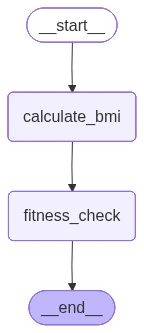

In [31]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())